# 📡 Telecom Customer Churn — Complete ML Pipeline

**Pipeline Overview:**
1. Data Loading & EDA
2. Feature Engineering
3. Train-Test Split
4. Encoding & Scaling
5. Class Imbalance Handling
6. Feature Selection
7. Model Training (LR · Decision Tree · Random Forest · XGBoost)
8. Cross-Validation & Hyperparameter Tuning
9. Model Comparison
10. Threshold Tuning on Best Model
11. ROC-AUC · Precision-Recall · Business Cost Curves
12. SHAP Interpretability

## 1️⃣  Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# Metrics
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score, precision_score,
    roc_auc_score, classification_report, confusion_matrix,
    roc_curve, precision_recall_curve, auc, ConfusionMatrixDisplay
)
from scipy.stats import loguniform, randint, uniform

# SHAP
import shap

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')
print('✅ All libraries imported successfully')

✅ All libraries imported successfully


## 2️⃣  Data Loading & Initial Inspection

In [2]:
df = pd.read_csv('tele_comm.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
print('--- Data Types ---')
print(df.dtypes)
print('\n--- Null Counts ---')
print(df.isnull().sum())
print('\n--- Basic Stats ---')
df.describe(include='all')

--- Data Types ---
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

--- Null Counts ---
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
Paperl

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,3186-AJIEK,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


In [4]:
# Fix TotalCharges dtype
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.loc[df['tenure'] == 0, 'TotalCharges'] = 0

# Drop customer ID (not a feature)
df.drop(columns=['customerID'], inplace=True)

# Encode target
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print('✅ Basic cleaning done')
print(f'Target distribution:\n{df["Churn"].value_counts()}')

✅ Basic cleaning done
Target distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64


## 3️⃣  Exploratory Data Analysis (EDA)

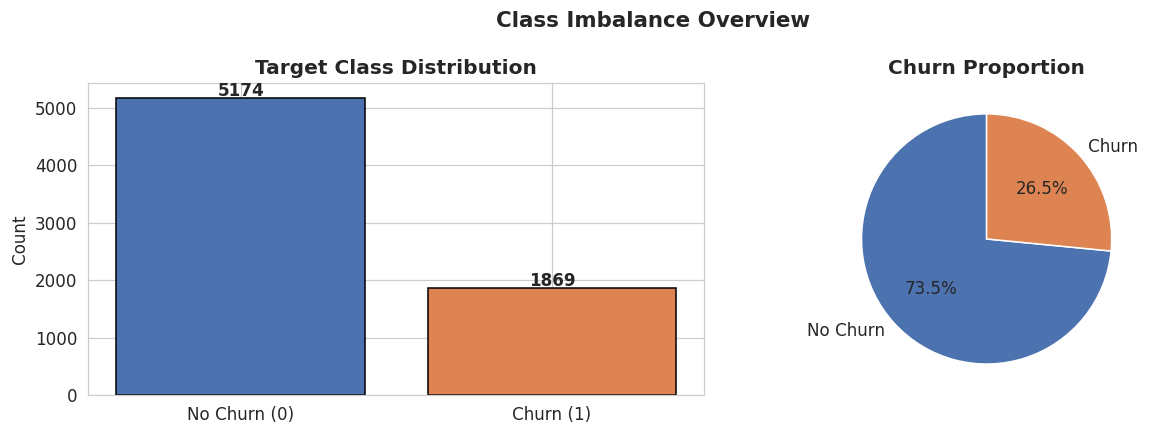

In [5]:
# --- Target Distribution ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

churn_counts = df['Churn'].value_counts()
axes[0].bar(['No Churn (0)', 'Churn (1)'], churn_counts.values, color=['#4C72B0', '#DD8452'], edgecolor='black')
axes[0].set_title('Target Class Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

axes[1].pie(churn_counts.values, labels=['No Churn', 'Churn'],
            autopct='%1.1f%%', colors=['#4C72B0', '#DD8452'], startangle=90)
axes[1].set_title('Churn Proportion', fontweight='bold')

plt.suptitle('Class Imbalance Overview', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

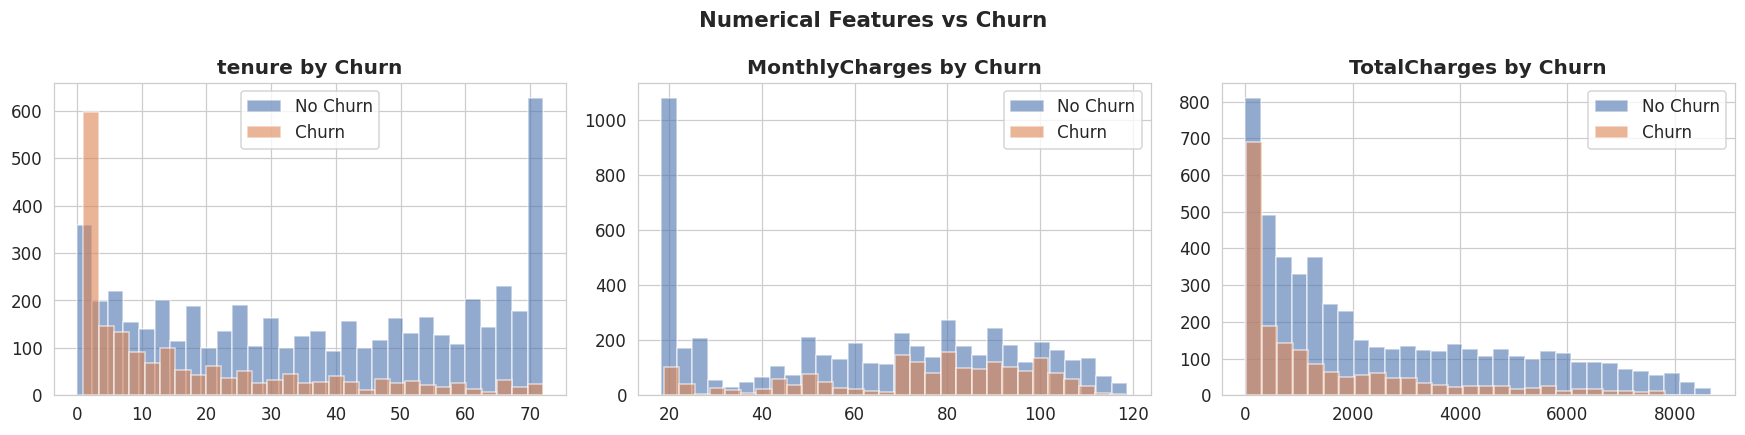

In [6]:
# --- Numerical Feature Distributions by Churn ---
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for i, col in enumerate(num_cols):
    df[df['Churn'] == 0][col].hist(ax=axes[i], alpha=0.6, bins=30, label='No Churn', color='#4C72B0')
    df[df['Churn'] == 1][col].hist(ax=axes[i], alpha=0.6, bins=30, label='Churn', color='#DD8452')
    axes[i].set_title(f'{col} by Churn', fontweight='bold')
    axes[i].legend()

plt.suptitle('Numerical Features vs Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

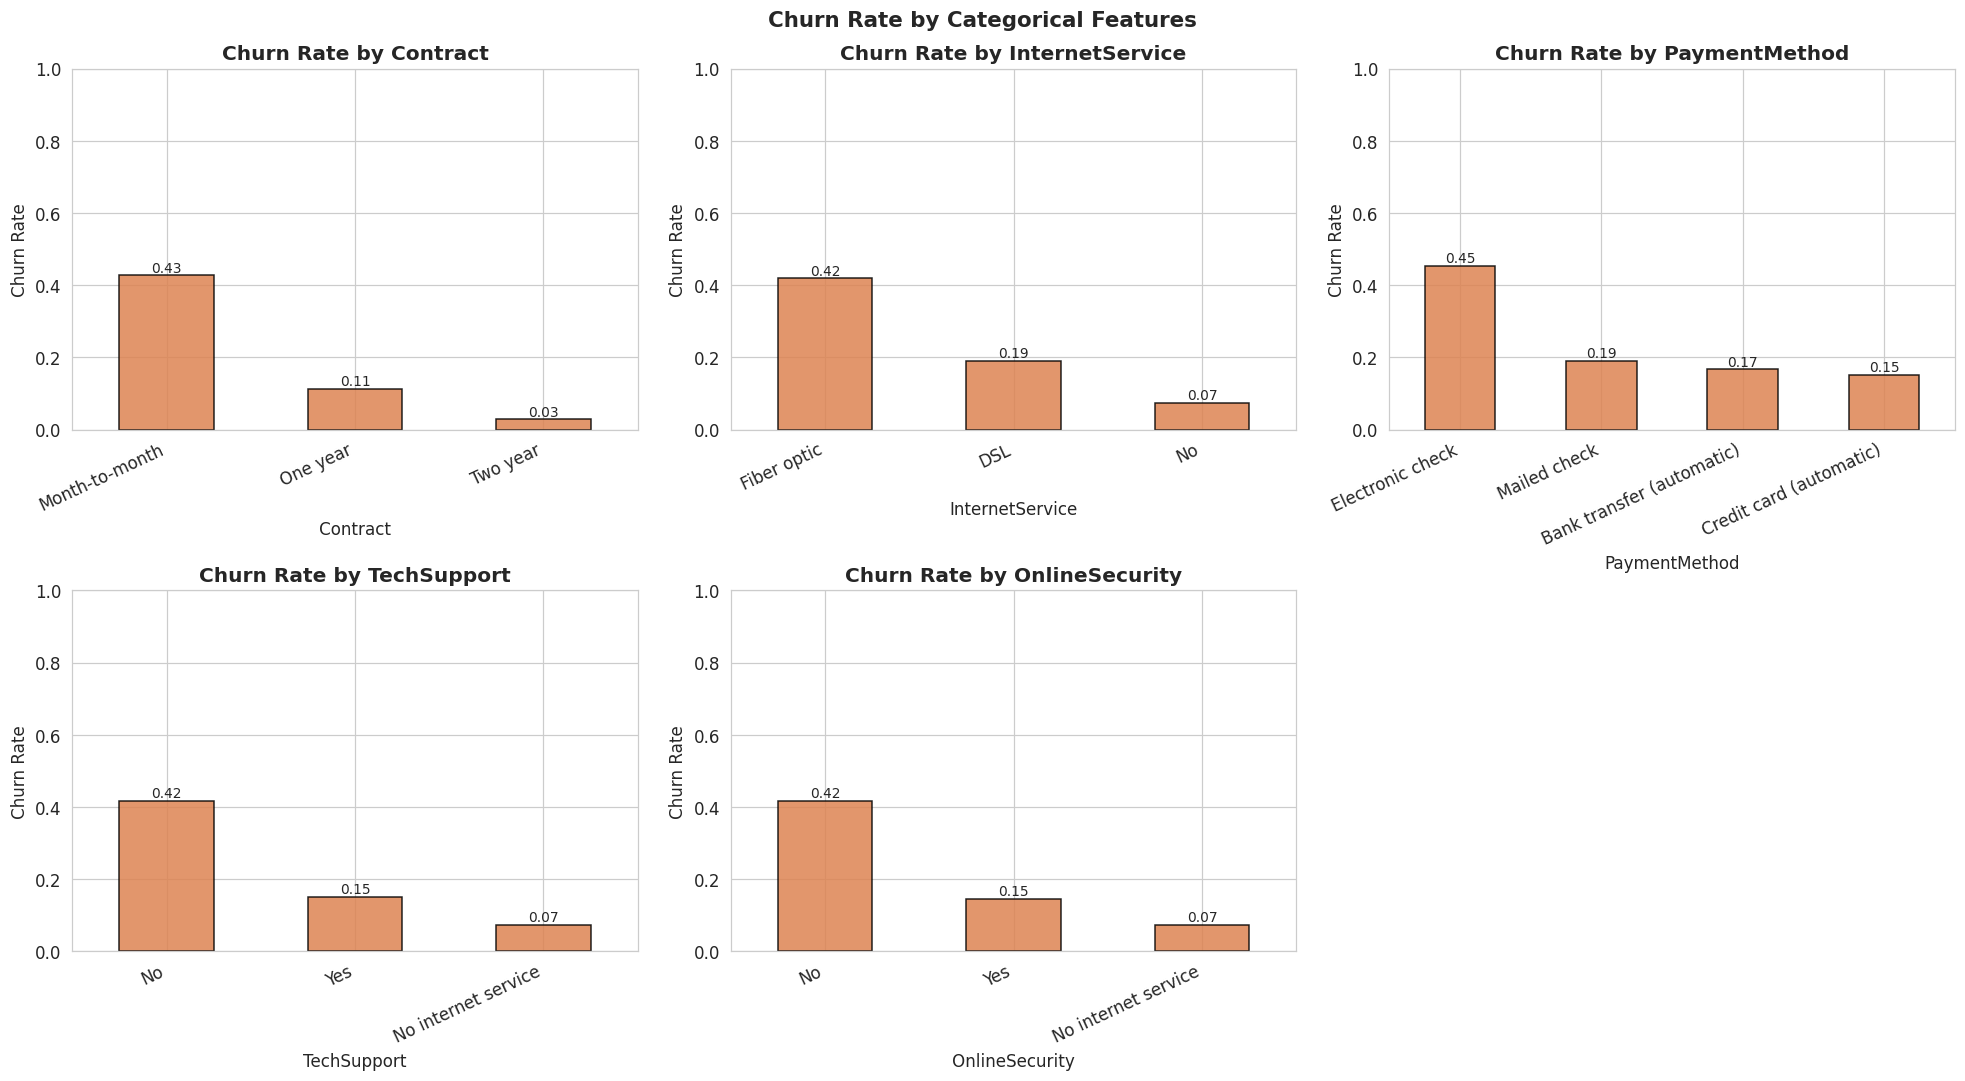

In [7]:
# --- Churn Rate by Categorical Features ---
cat_cols = ['Contract', 'InternetService', 'PaymentMethod', 'TechSupport', 'OnlineSecurity']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    churn_rate = df.groupby(col)['Churn'].mean().sort_values(ascending=False)
    churn_rate.plot(kind='bar', ax=axes[i], color='#DD8452', edgecolor='black', alpha=0.85)
    axes[i].set_title(f'Churn Rate by {col}', fontweight='bold')
    axes[i].set_ylabel('Churn Rate')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=25, ha='right')
    axes[i].set_ylim(0, 1)
    for bar in axes[i].patches:
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                     f'{bar.get_height():.2f}', ha='center', fontsize=9)

axes[-1].set_visible(False)
plt.suptitle('Churn Rate by Categorical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

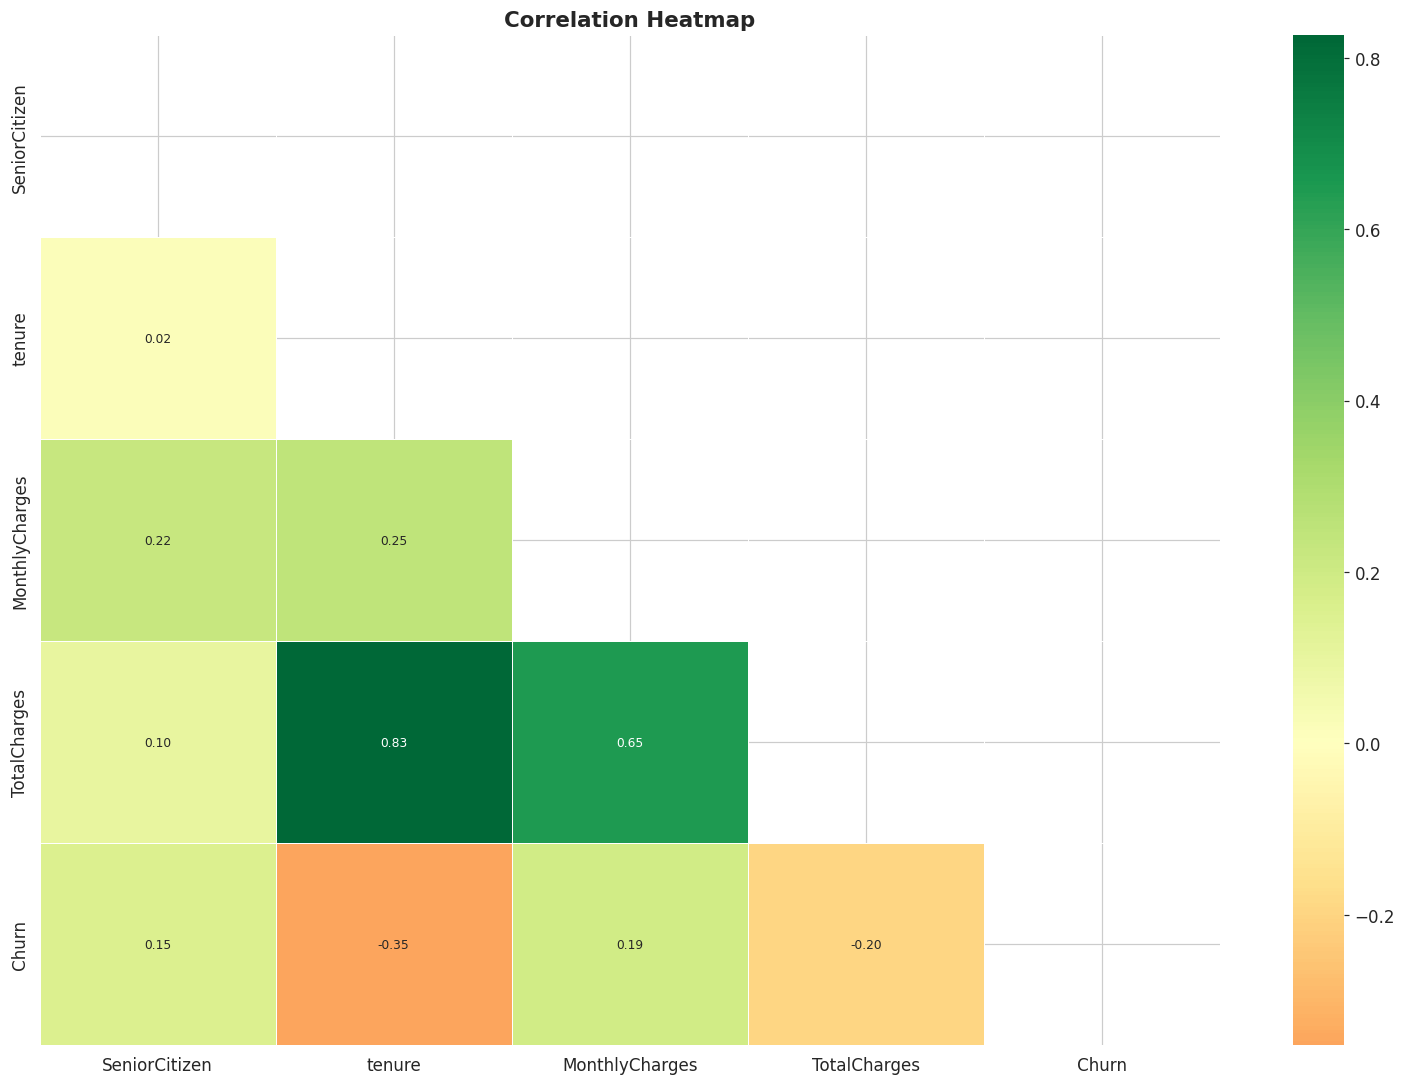

In [8]:
# --- Correlation Heatmap (numeric cols only) ---
num_df = df.select_dtypes(include=[np.number])
corr = num_df.corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, annot_kws={'size': 8})
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4️⃣  Feature Engineering

In [9]:
# ── Tenure-based Features ──────────────────────────────────────────────
df['TenureGroup'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 24, 48, float('inf')],
    labels=['New', 'Regular', 'Established', 'Loyal']
)
df['IsFirstYear']  = (df['tenure'] <= 12).astype(int)
df['IsLongTerm']   = (df['tenure'] >= 24).astype(int)

# ── Charge-based Features ─────────────────────────────────────────────
df['AvgMonthlyCharge'] = df.apply(
    lambda x: x['TotalCharges'] / x['tenure'] if x['tenure'] > 0 else x['MonthlyCharges'],
    axis=1
)
df['CustomerLTV'] = df['TotalCharges'] + (df['MonthlyCharges'] * 6)

# ── Service-based Features ────────────────────────────────────────────
additional_services = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                       'TechSupport', 'StreamingTV', 'StreamingMovies']
df['NumAdditionalServices'] = df[additional_services].apply(
    lambda x: (x == 'Yes').sum(), axis=1
)
df['HasSecurityBundle']  = ((df['OnlineSecurity'] == 'Yes') & (df['OnlineBackup'] == 'Yes')).astype(int)
df['HasStreamingBundle'] = ((df['StreamingTV'] == 'Yes') & (df['StreamingMovies'] == 'Yes')).astype(int)
df['InternetUser']       = (df['InternetService'] != 'No').astype(int)
df['FiberOpticUser']     = (df['InternetService'] == 'Fiber optic').astype(int)
df['ServicesPerMonth']   = df['NumAdditionalServices'] / (df['tenure'] + 1)

# ── Contract / Payment Features ───────────────────────────────────────
df['IsMonthToMonth'] = (df['Contract'] == 'Month-to-month').astype(int)
df['ContractType']   = df['Contract'].map({'Month-to-month': 0, 'One year': 1, 'Two year': 2})
df['ElectronicPayment'] = df['PaymentMethod'].str.contains('electronic check|automatic', case=False).astype(int)
df['PaymentRisk'] = df['PaymentMethod'].map({
    'Electronic check': 3, 'Mailed check': 2,
    'Bank transfer (automatic)': 1, 'Credit card (automatic)': 1
})
df['PaperlessBilling'] = df['PaperlessBilling'].map({'Yes': 1, 'No': 0}) if df['PaperlessBilling'].dtype == 'object' else df['PaperlessBilling']
df['PaperlessHighRisk'] = ((df['PaperlessBilling'] == 1) & (df['PaymentMethod'] == 'Electronic check')).astype(int)

# ── Family / Demographic Features ────────────────────────────────────
df['Partner']    = df['Partner'].map({'Yes': 1, 'No': 0}) if df['Partner'].dtype == 'object' else df['Partner']
df['Dependents'] = df['Dependents'].map({'Yes': 1, 'No': 0}) if df['Dependents'].dtype == 'object' else df['Dependents']
df['HasFamily']  = ((df['Partner'] == 1) | (df['Dependents'] == 1)).astype(int)

# ── Risk / Engagement Features ────────────────────────────────────────
df['HighCostLowTenure'] = (
    (df['MonthlyCharges'] > df['MonthlyCharges'].median()) & (df['tenure'] < 12)
).astype(int)

df['EngagementScore'] = (
    df['NumAdditionalServices'] * 0.3 +
    df['ContractType'] * 0.4 +
    (df['tenure'] / df['tenure'].max()) * 0.3
)

print(f'✅ Feature engineering done — shape: {df.shape}')
print(f'Columns: {list(df.columns)}')

✅ Feature engineering done — shape: (7043, 39)
Columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'TenureGroup', 'IsFirstYear', 'IsLongTerm', 'AvgMonthlyCharge', 'CustomerLTV', 'NumAdditionalServices', 'HasSecurityBundle', 'HasStreamingBundle', 'InternetUser', 'FiberOpticUser', 'ServicesPerMonth', 'IsMonthToMonth', 'ContractType', 'ElectronicPayment', 'PaymentRisk', 'PaperlessHighRisk', 'HasFamily', 'HighCostLowTenure', 'EngagementScore']


## 5️⃣  Train-Test Split

In [10]:
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train size : {X_train.shape[0]} rows ({y_train.mean():.2%} churn)')
print(f'Test  size : {X_test.shape[0]} rows ({y_test.mean():.2%} churn)')

Train size : 5634 rows (26.54% churn)
Test  size : 1409 rows (26.54% churn)


## 6️⃣  Encoding & Scaling

In [11]:
# One-Hot Encode categorical columns
X_train_enc = pd.get_dummies(X_train, drop_first=True)
X_test_enc  = pd.get_dummies(X_test,  drop_first=True)

# Align columns (test may be missing some dummies)
X_train_enc, X_test_enc = X_train_enc.align(X_test_enc, join='outer', axis=1, fill_value=0)

# Ensure bool columns are int
X_train_enc = X_train_enc.astype(float)
X_test_enc  = X_test_enc.astype(float)

print(f'Post-encoding shape — Train: {X_train_enc.shape}, Test: {X_test_enc.shape}')

Post-encoding shape — Train: (5634, 51), Test: (1409, 51)


In [12]:
# Standard Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_enc)
X_test_scaled  = scaler.transform(X_test_enc)

feature_names = X_train_enc.columns.tolist()
print(f'✅ Scaling done — {len(feature_names)} features')

✅ Scaling done — 51 features


## 7️⃣  Feature Selection (L1 / Lasso)

✅ Features selected: 32 / 51
Dropped: 19 features


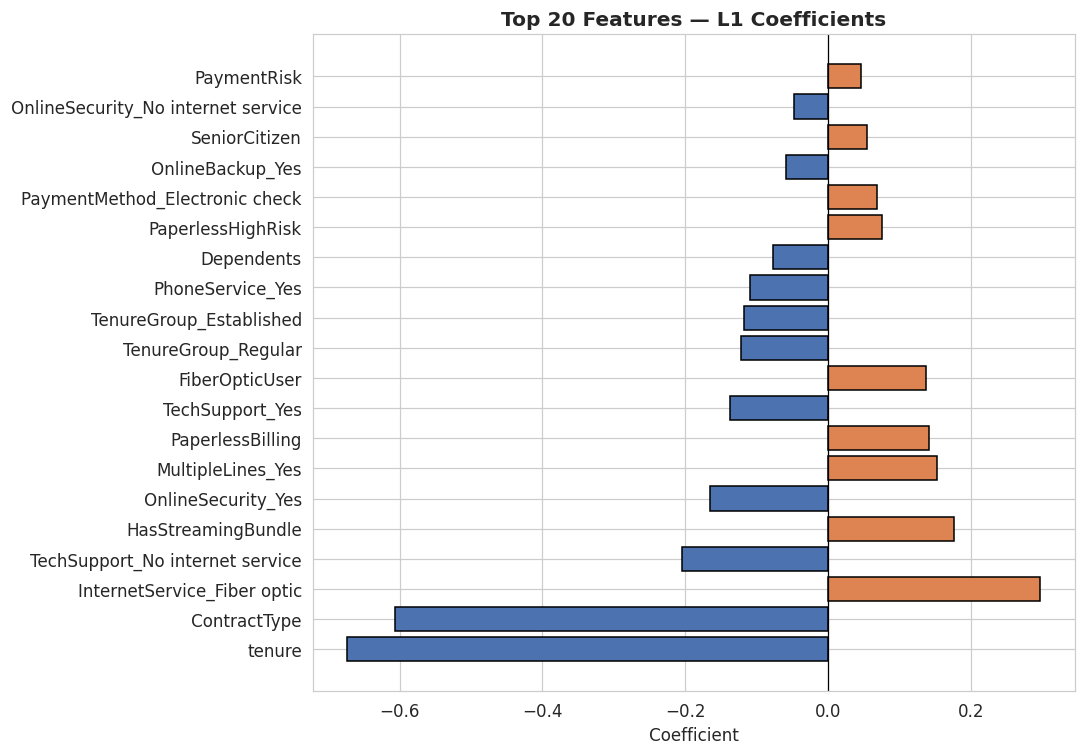

In [13]:
# L1 Logistic Regression to eliminate zero-weight features
l1_selector = LogisticRegression(penalty='l1', solver='liblinear', C=0.1,
                                  max_iter=1000, random_state=42)
l1_selector.fit(X_train_scaled, y_train)

l1_mask          = l1_selector.coef_[0] != 0
selected_features = np.array(feature_names)[l1_mask]

X_train_sel = X_train_scaled[:, l1_mask]
X_test_sel  = X_test_scaled[:,  l1_mask]

print(f'✅ Features selected: {len(selected_features)} / {len(feature_names)}')
print(f'Dropped: {len(feature_names) - len(selected_features)} features')

# Visualise feature importances from L1 coefficients
coef_df = pd.DataFrame({
    'Feature': selected_features,
    'Coefficient': l1_selector.coef_[0][l1_mask]
}).sort_values('Coefficient', key=abs, ascending=False).head(20)

plt.figure(figsize=(10, 7))
colors = ['#DD8452' if c > 0 else '#4C72B0' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='black')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top 20 Features — L1 Coefficients', fontweight='bold')
plt.xlabel('Coefficient')
plt.tight_layout()
plt.show()

## 8️⃣  Handling Class Imbalance (SMOTE)

Before SMOTE: Counter({0: 4139, 1: 1495})
After  SMOTE: Counter({0: 4139, 1: 4139})


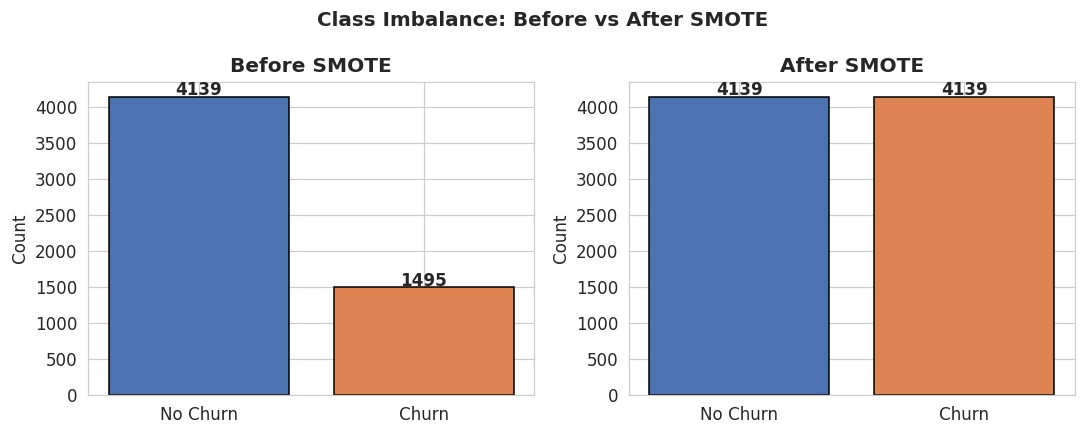

In [14]:
from collections import Counter

print('Before SMOTE:', Counter(y_train))

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_sel, y_train)

print('After  SMOTE:', Counter(y_train_res))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, counts, title in zip(
    axes,
    [Counter(y_train), Counter(y_train_res)],
    ['Before SMOTE', 'After SMOTE']
):
    ax.bar(['No Churn', 'Churn'], [counts[0], counts[1]],
           color=['#4C72B0', '#DD8452'], edgecolor='black')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Count')
    for i, v in enumerate([counts[0], counts[1]]):
        ax.text(i, v + 20, str(v), ha='center', fontweight='bold')
plt.suptitle('Class Imbalance: Before vs After SMOTE', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 9️⃣  Model Training with Cross-Validation

> All four models are evaluated with 5-fold Stratified CV **before** hyperparameter tuning.

In [15]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

base_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'      : DecisionTreeClassifier(random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost'            : XGBClassifier(use_label_encoder=False, eval_metric='logloss',
                                         random_state=42, n_jobs=-1)
}

cv_results = {}
metrics_to_track = ['roc_auc', 'f1', 'recall', 'precision']

for name, model in base_models.items():
    scores = {}
    for metric in metrics_to_track:
        s = cross_val_score(model, X_train_res, y_train_res, cv=cv, scoring=metric, n_jobs=-1)
        scores[metric] = s
    cv_results[name] = scores
    print(f'{name:25s}  AUC={scores["roc_auc"].mean():.4f}  F1={scores["f1"].mean():.4f}  '
          f'Recall={scores["recall"].mean():.4f}  Precision={scores["precision"].mean():.4f}')

print('\n✅ Cross-validation complete')

Logistic Regression        AUC=0.8485  F1=0.7731  Recall=0.7997  Precision=0.7486
Decision Tree              AUC=0.7990  F1=0.7950  Recall=0.7956  Precision=0.7947
Random Forest              AUC=0.9162  F1=0.8454  Recall=0.8488  Precision=0.8422
XGBoost                    AUC=0.9286  F1=0.8463  Recall=0.8497  Precision=0.8431

✅ Cross-validation complete


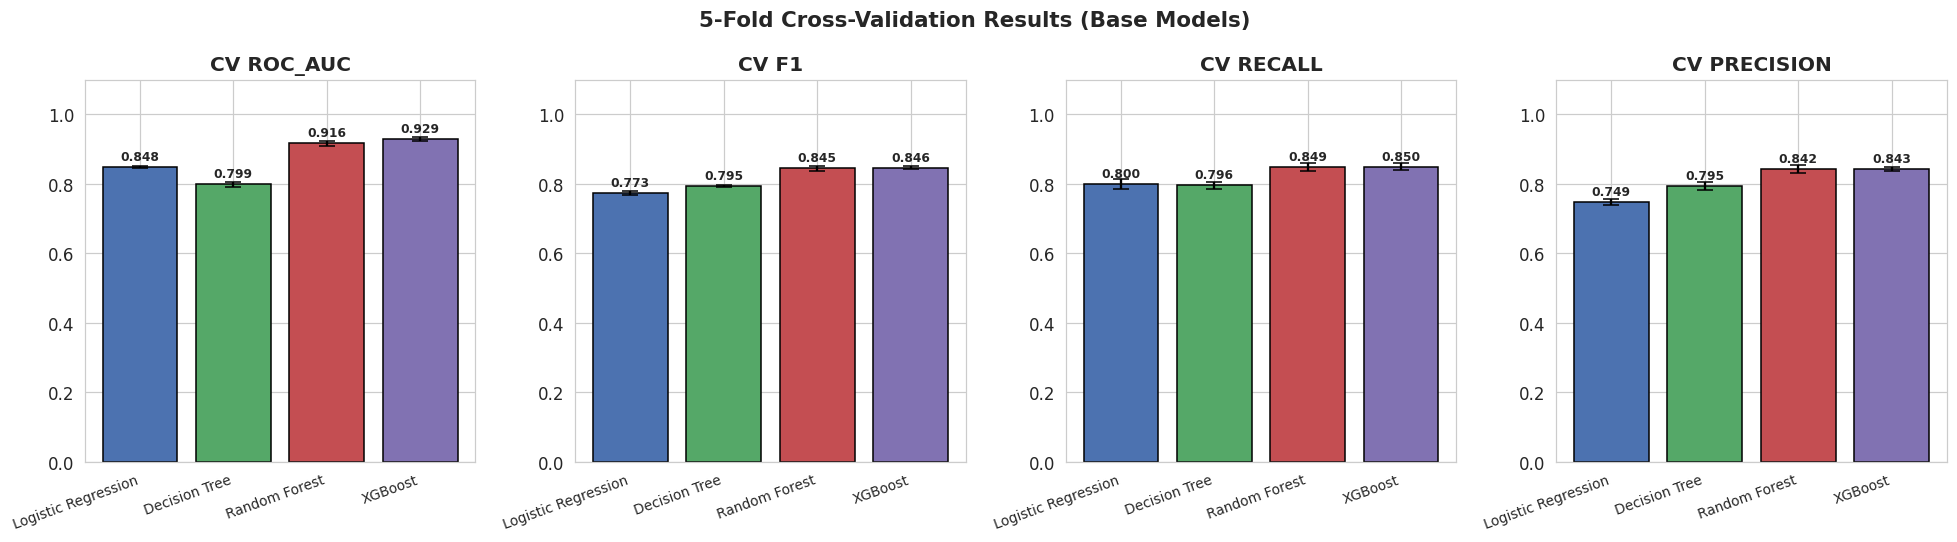

In [16]:
# --- CV Results Visualisation ---
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, metric in zip(axes, metrics_to_track):
    means  = [cv_results[n][metric].mean() for n in base_models]
    stds   = [cv_results[n][metric].std()  for n in base_models]
    colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']
    bars   = ax.bar(base_models.keys(), means, yerr=stds, capsize=5, color=colors, edgecolor='black')
    ax.set_title(f'CV {metric.upper()}', fontweight='bold')
    ax.set_ylim(0, 1.1)
    ax.set_xticklabels(list(base_models.keys()), rotation=20, ha='right', fontsize=9)
    for bar, m in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{m:.3f}', ha='center', fontsize=8, fontweight='bold')

plt.suptitle('5-Fold Cross-Validation Results (Base Models)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 🔟  Hyperparameter Tuning (RandomizedSearchCV)

In [17]:
# ── Logistic Regression ─────────────────────────────────────────────────
lr_param_dist = {
    'C'      : loguniform(0.01, 10),
    'penalty': ['l1', 'l2'],
    'solver' : ['liblinear'],
    'max_iter': [500, 1000]
}
lr_search = RandomizedSearchCV(
    LogisticRegression(random_state=42), lr_param_dist,
    n_iter=20, cv=cv, scoring='roc_auc', n_jobs=-1, random_state=42
)
lr_search.fit(X_train_res, y_train_res)
print('LR  best params :', lr_search.best_params_,  '| CV AUC:', round(lr_search.best_score_, 4))

LR  best params : {'C': np.float64(0.59874749104614), 'max_iter': 500, 'penalty': 'l1', 'solver': 'liblinear'} | CV AUC: 0.8484


In [18]:
# ── Decision Tree ────────────────────────────────────────────────────────
dt_param_dist = {
    'max_depth'       : randint(3, 20),
    'min_samples_split': randint(2, 50),
    'min_samples_leaf' : randint(1, 30),
    'criterion'        : ['gini', 'entropy']
}
dt_search = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=42), dt_param_dist,
    n_iter=30, cv=cv, scoring='roc_auc', n_jobs=-1, random_state=42
)
dt_search.fit(X_train_res, y_train_res)
print('DT  best params :', dt_search.best_params_, '| CV AUC:', round(dt_search.best_score_, 4))

DT  best params : {'criterion': 'entropy', 'max_depth': 15, 'min_samples_leaf': 9, 'min_samples_split': 30} | CV AUC: 0.8821


In [19]:
# ── Random Forest ────────────────────────────────────────────────────────
rf_param_dist = {
    'n_estimators'    : randint(100, 500),
    'max_depth'       : [None, 10, 20, 30],
    'min_samples_split': randint(2, 20),
    'min_samples_leaf' : randint(1, 15),
    'max_features'     : ['sqrt', 'log2']
}
rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1), rf_param_dist,
    n_iter=30, cv=cv, scoring='roc_auc', n_jobs=-1, random_state=42
)
rf_search.fit(X_train_res, y_train_res)
print('RF  best params :', rf_search.best_params_, '| CV AUC:', round(rf_search.best_score_, 4))

RF  best params : {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 6, 'n_estimators': 330} | CV AUC: 0.9188


In [20]:
# ── XGBoost ──────────────────────────────────────────────────────────────
xgb_param_dist = {
    'n_estimators'  : randint(100, 500),
    'max_depth'     : randint(3, 10),
    'learning_rate' : uniform(0.01, 0.3),
    'subsample'     : uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'gamma'         : uniform(0, 0.5),
    'reg_alpha'     : uniform(0, 1),
    'reg_lambda'    : uniform(1, 2)
}
xgb_search = RandomizedSearchCV(
    XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, n_jobs=-1),
    xgb_param_dist, n_iter=40, cv=cv, scoring='roc_auc', n_jobs=-1, random_state=42
)
xgb_search.fit(X_train_res, y_train_res)
print('XGB best params :', xgb_search.best_params_, '| CV AUC:', round(xgb_search.best_score_, 4))

XGB best params : {'colsample_bytree': np.float64(0.6557975442608167), 'gamma': np.float64(0.14607232426760908), 'learning_rate': np.float64(0.1199085529881075), 'max_depth': 8, 'n_estimators': 274, 'reg_alpha': np.float64(0.6183860093330873), 'reg_lambda': np.float64(1.7649239825343255), 'subsample': np.float64(0.9932923543227152)} | CV AUC: 0.9335


## 1️⃣1️⃣  Model Comparison on Test Set

In [21]:
tuned_models = {
    'Logistic Regression': lr_search.best_estimator_,
    'Decision Tree'      : dt_search.best_estimator_,
    'Random Forest'      : rf_search.best_estimator_,
    'XGBoost'            : xgb_search.best_estimator_
}

results = []

for name, model in tuned_models.items():
    y_prob = model.predict_proba(X_test_sel)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    results.append({
        'Model'    : name,
        'Accuracy' : accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall'   : recall_score(y_test, y_pred),
        'F1'       : f1_score(y_test, y_pred),
        'ROC-AUC'  : roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results).set_index('Model').round(4)
print(results_df.to_string())
results_df

                     Accuracy  Precision  Recall      F1  ROC-AUC
Model                                                            
Logistic Regression    0.7424     0.5094  0.7968  0.6215   0.8392
Decision Tree          0.7310     0.4950  0.6631  0.5669   0.7893
Random Forest          0.7750     0.5697  0.6230  0.5951   0.8249
XGBoost                0.7750     0.5711  0.6123  0.5910   0.8316


,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Logistic Regression,0.7424,0.5094,0.7968,0.6215,0.8392
Decision Tree,0.7310,0.4950,0.6631,0.5669,0.7893
Random Forest,0.7750,0.5697,0.6230,0.5951,0.8249
XGBoost,0.7750,0.5711,0.6123,0.5910,0.8316


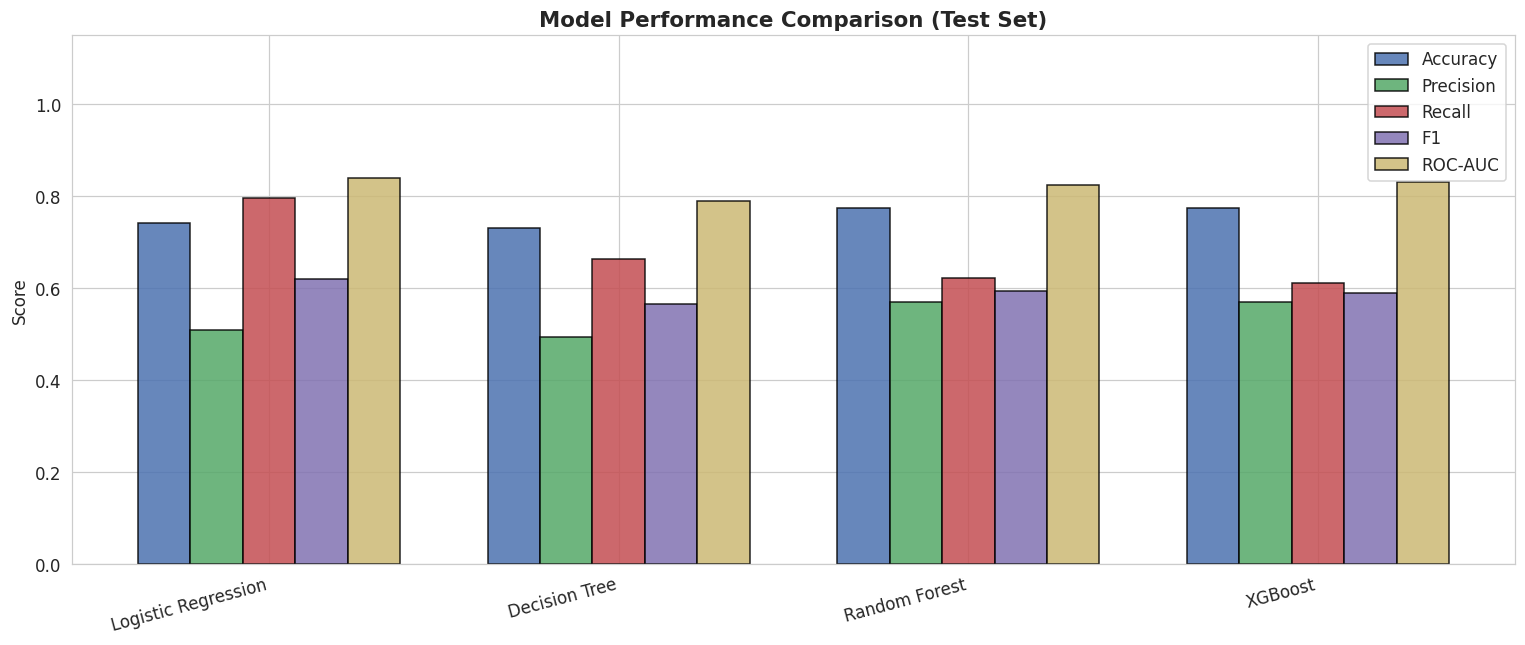


🏆 Best model by ROC-AUC: Logistic Regression (0.8392)


In [22]:
# --- Visual Comparison ---
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(results_df))
width = 0.15
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974']

for i, (metric, color) in enumerate(zip(metrics, colors)):
    bars = ax.bar(x + i * width, results_df[metric], width, label=metric, color=color, edgecolor='black', alpha=0.85)

ax.set_xticks(x + width * 2)
ax.set_xticklabels(results_df.index, rotation=15, ha='right')
ax.set_ylim(0, 1.15)
ax.set_title('Model Performance Comparison (Test Set)', fontsize=14, fontweight='bold')
ax.legend(loc='upper right')
ax.set_ylabel('Score')
plt.tight_layout()
plt.show()

# Identify best model by ROC-AUC
best_model_name = results_df['ROC-AUC'].idxmax()
print(f'\n🏆 Best model by ROC-AUC: {best_model_name} ({results_df.loc[best_model_name, "ROC-AUC"]:.4f})')

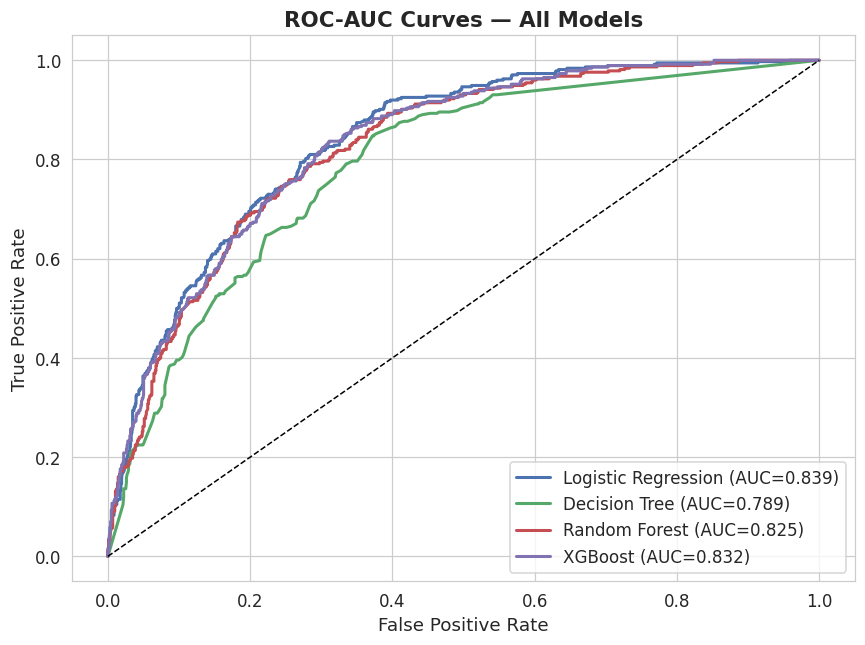

In [23]:
# --- ROC Curves — All 4 Models ---
plt.figure(figsize=(8, 6))
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

for (name, model), color in zip(tuned_models.items(), colors):
    y_prob = model.predict_proba(X_test_sel)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC={roc_auc:.3f})', color=color, linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC-AUC Curves — All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

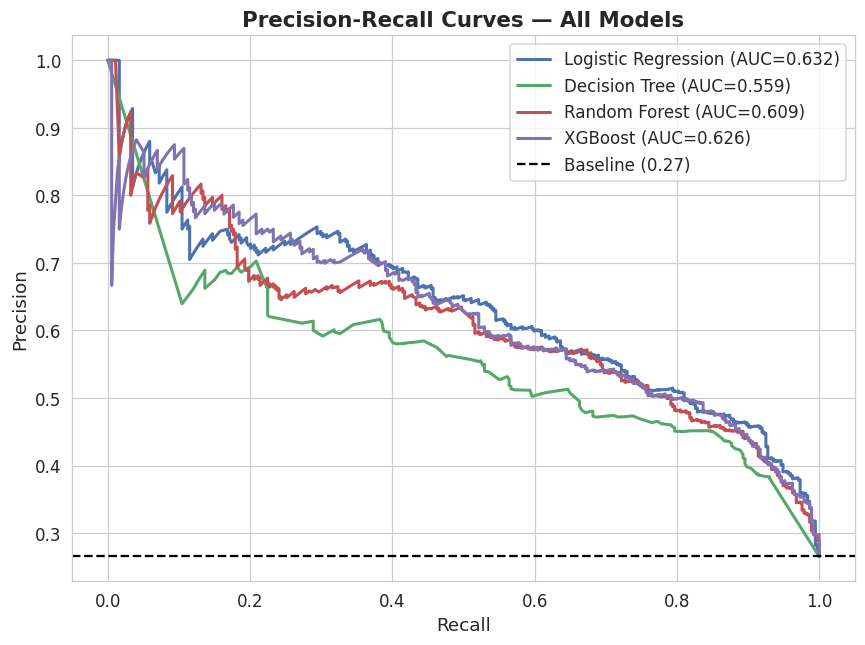

In [24]:
# --- Precision-Recall Curves — All 4 Models ---
plt.figure(figsize=(8, 6))

for (name, model), color in zip(tuned_models.items(), colors):
    y_prob = model.predict_proba(X_test_sel)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, label=f'{name} (AUC={pr_auc:.3f})', color=color, linewidth=2)

baseline = y_test.mean()
plt.axhline(baseline, color='black', linestyle='--', label=f'Baseline ({baseline:.2f})')
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curves — All Models', fontsize=14, fontweight='bold')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

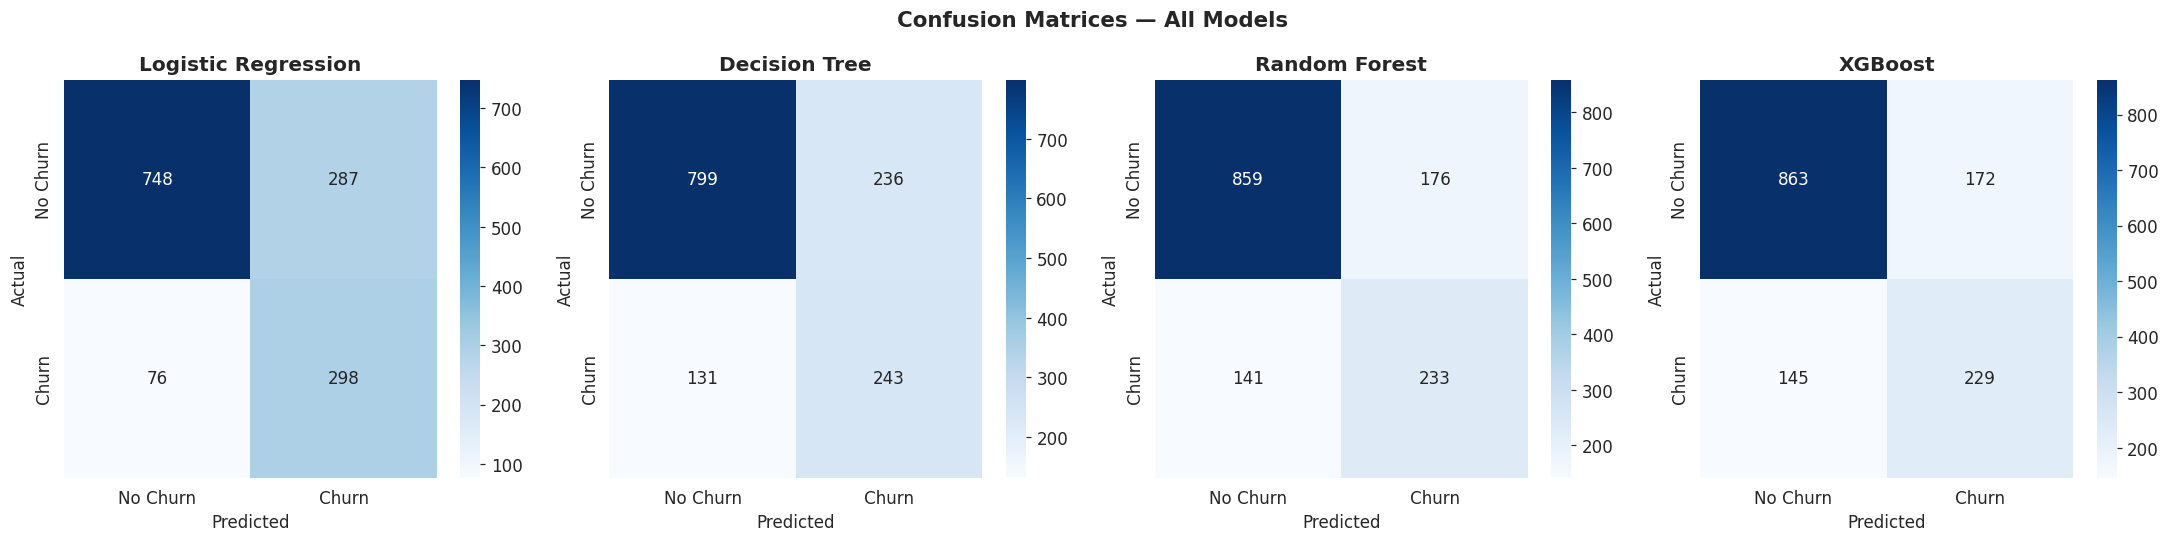

In [25]:
# --- Confusion Matrices — All 4 Models ---
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, (name, model) in zip(axes, tuned_models.items()):
    y_pred = model.predict(X_test_sel)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn'])
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 1️⃣2️⃣  Threshold Tuning on Best Model

> In churn prediction, **recall is business-critical** (missing a churner = lost revenue).  
> We tune the decision threshold to balance Precision vs Recall and minimise business cost.

In [26]:
best_model = tuned_models[best_model_name]
y_prob_best = best_model.predict_proba(X_test_sel)[:, 1]

thresholds = np.arange(0.1, 0.91, 0.05)

threshold_results = []
for t in thresholds:
    y_pred_t = (y_prob_best >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
    threshold_results.append({
        'Threshold': round(t, 2),
        'Precision': precision_score(y_test, y_pred_t, zero_division=0),
        'Recall'   : recall_score(y_test, y_pred_t),
        'F1'       : f1_score(y_test, y_pred_t),
        'ROC-AUC'  : roc_auc_score(y_test, y_prob_best),
        'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp
    })

thresh_df = pd.DataFrame(threshold_results)
thresh_df

,Threshold,Precision,Recall,F1,ROC-AUC,TN,FP,FN,TP
0,0.10,0.342301,0.986631,0.508264,0.839242,326,709,5,369
1,0.15,0.370295,0.973262,0.536478,0.839242,416,619,10,364
2,0.20,0.390969,0.949198,0.553822,0.839242,482,553,19,355
3,0.25,0.409624,0.933155,0.569331,0.839242,532,503,25,349
4,0.30,0.427340,0.927807,0.585160,0.839242,570,465,27,347
5,0.35,0.451444,0.919786,0.605634,0.839242,617,418,30,344
6,0.40,0.466006,0.879679,0.609259,0.839242,658,377,45,329
7,0.45,0.489699,0.826203,0.614925,0.839242,713,322,65,309
8,0.50,0.509402,0.796791,0.621481,0.839242,748,287,76,298
9,0.55,0.527514,0.743316,0.617092,0.839242,786,249,96,278


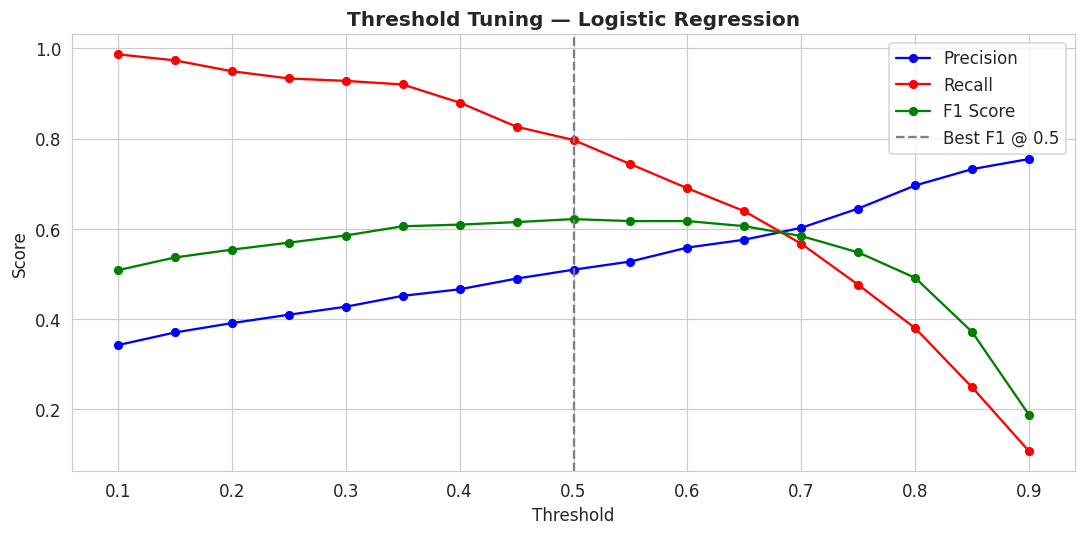

Best F1 threshold: 0.5


In [27]:
# --- Precision-Recall-F1 vs Threshold ---
plt.figure(figsize=(10, 5))
plt.plot(thresh_df['Threshold'], thresh_df['Precision'], 'b-o', label='Precision', markersize=5)
plt.plot(thresh_df['Threshold'], thresh_df['Recall'],    'r-o', label='Recall',    markersize=5)
plt.plot(thresh_df['Threshold'], thresh_df['F1'],        'g-o', label='F1 Score',  markersize=5)

best_f1_thresh = thresh_df.loc[thresh_df['F1'].idxmax(), 'Threshold']
plt.axvline(best_f1_thresh, color='gray', linestyle='--', label=f'Best F1 @ {best_f1_thresh}')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title(f'Threshold Tuning — {best_model_name}', fontweight='bold')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f'Best F1 threshold: {best_f1_thresh}')

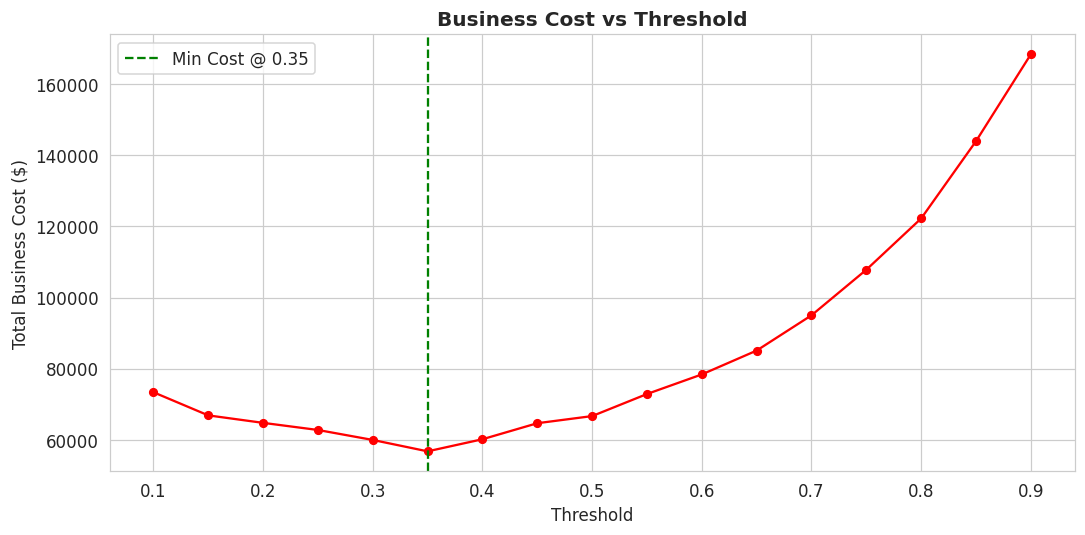

Best Business Cost threshold: 0.35
Min Business Cost          : $56,800


In [28]:
# --- Business Cost vs Threshold ---
# FP cost: sending retention offer to non-churner = $100
# FN cost: missing a churner = $500
FP_COST = 100
FN_COST = 500

thresh_df['BusinessCost'] = thresh_df['FP'] * FP_COST + thresh_df['FN'] * FN_COST

best_cost_thresh = thresh_df.loc[thresh_df['BusinessCost'].idxmin(), 'Threshold']

plt.figure(figsize=(10, 5))
plt.plot(thresh_df['Threshold'], thresh_df['BusinessCost'], 'r-o', markersize=5)
plt.axvline(best_cost_thresh, color='green', linestyle='--', label=f'Min Cost @ {best_cost_thresh}')
plt.xlabel('Threshold')
plt.ylabel('Total Business Cost ($)')
plt.title('Business Cost vs Threshold', fontweight='bold')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f'Best Business Cost threshold: {best_cost_thresh}')
print(f'Min Business Cost          : ${thresh_df["BusinessCost"].min():,.0f}')

=== Final Evaluation @ threshold=0.35 ===
Model: Logistic Regression

              precision    recall  f1-score   support

    No Churn       0.95      0.60      0.73      1035
       Churn       0.45      0.92      0.61       374

    accuracy                           0.68      1409
   macro avg       0.70      0.76      0.67      1409
weighted avg       0.82      0.68      0.70      1409

ROC-AUC: 0.8392


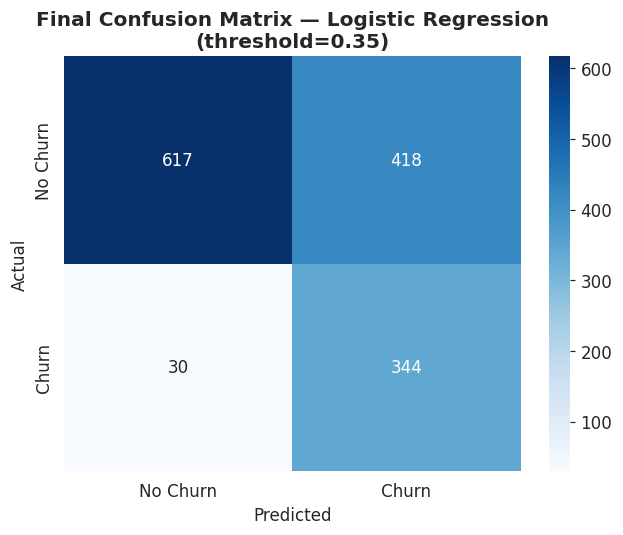

In [29]:
# --- Final Evaluation at Optimal Threshold ---
optimal_threshold = best_cost_thresh
y_pred_final = (y_prob_best >= optimal_threshold).astype(int)

print(f'=== Final Evaluation @ threshold={optimal_threshold} ===')
print(f'Model: {best_model_name}\n')
print(classification_report(y_test, y_pred_final, target_names=['No Churn', 'Churn']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_best):.4f}')

# Final Confusion Matrix
cm_final = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title(f'Final Confusion Matrix — {best_model_name}\n(threshold={optimal_threshold})', fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## 1️⃣3️⃣  SHAP — Model Interpretability

In [30]:
# Prepare DataFrame for SHAP (needs feature names)
X_test_sel_df = pd.DataFrame(X_test_sel, columns=selected_features)
X_train_sel_df = pd.DataFrame(X_train_res, columns=selected_features)

# Use TreeExplainer for tree-based models, LinearExplainer for LR
if best_model_name == 'Logistic Regression':
    explainer = shap.LinearExplainer(best_model, X_train_sel_df)
else:
    explainer = shap.TreeExplainer(best_model)

shap_values = explainer.shap_values(X_test_sel_df)

# For binary classifiers that return list of arrays, take class=1 values
if isinstance(shap_values, list):
    shap_vals = shap_values[1]
else:
    shap_vals = shap_values

print(f'SHAP values shape: {shap_vals.shape}')

SHAP values shape: (1409, 32)


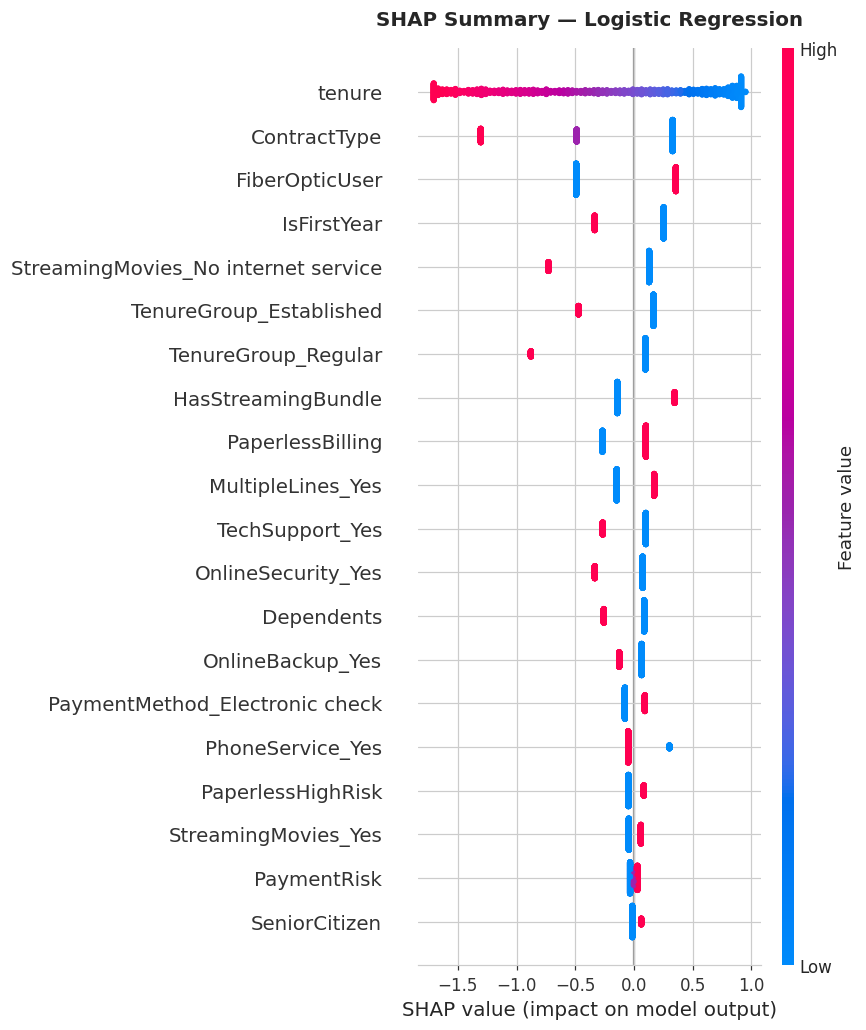

In [31]:
# --- SHAP Summary Plot (Beeswarm) ---
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_vals, X_test_sel_df, plot_type='dot', show=False, max_display=20)
plt.title(f'SHAP Summary — {best_model_name}', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

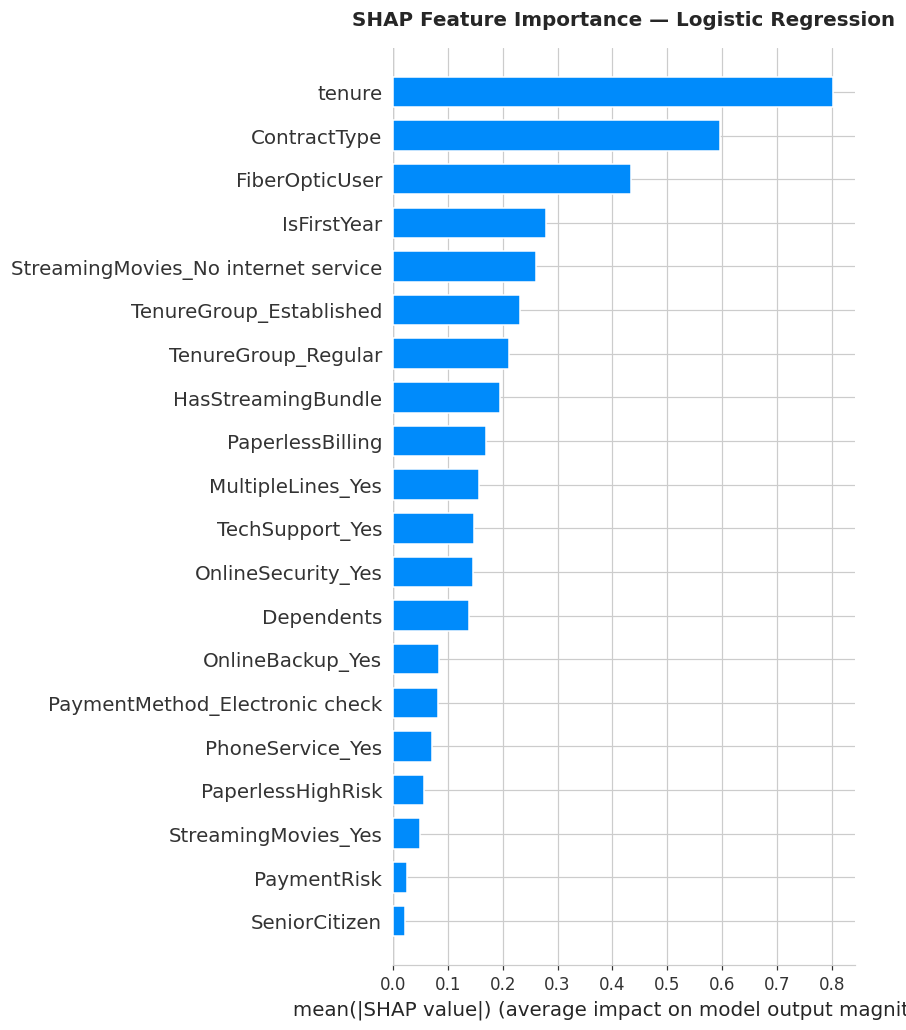

In [32]:
# --- SHAP Bar Plot (Mean Absolute Values) ---
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_vals, X_test_sel_df, plot_type='bar', show=False, max_display=20)
plt.title(f'SHAP Feature Importance — {best_model_name}', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

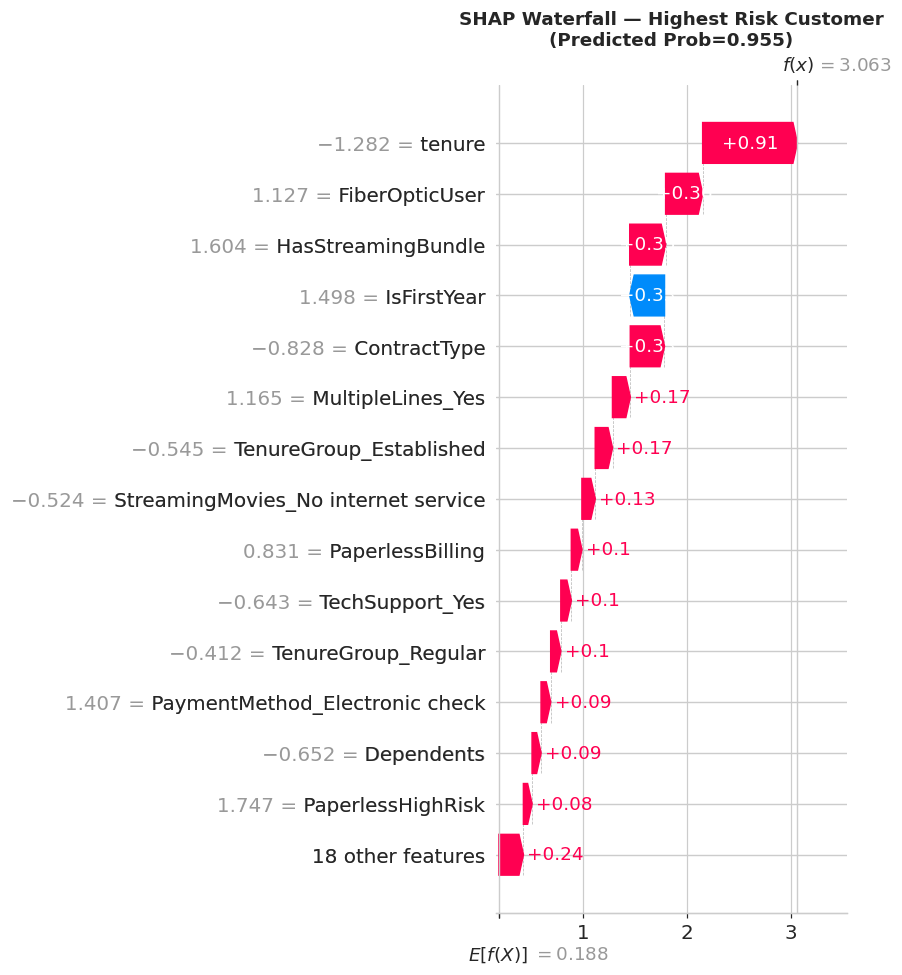

In [33]:
# --- SHAP Waterfall Plot — Single Prediction (highest churn probability) ---
high_risk_idx = np.argmax(y_prob_best)

expected_value = explainer.expected_value
if isinstance(expected_value, list):
    expected_value = expected_value[1]

shap_explanation = shap.Explanation(
    values        = shap_vals[high_risk_idx],
    base_values   = expected_value,
    data          = X_test_sel_df.iloc[high_risk_idx].values,
    feature_names = selected_features
)

plt.figure(figsize=(10, 6))
shap.waterfall_plot(shap_explanation, max_display=15, show=False)
plt.title(f'SHAP Waterfall — Highest Risk Customer\n(Predicted Prob={y_prob_best[high_risk_idx]:.3f})',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

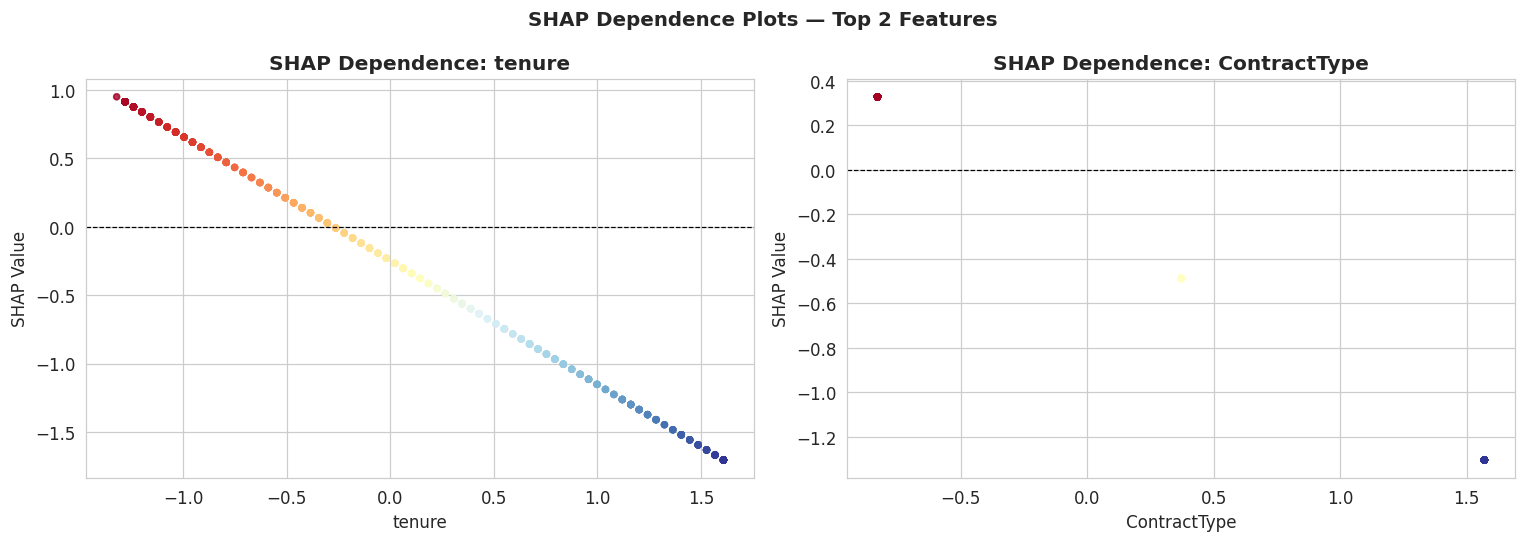

In [34]:
# --- SHAP Dependence Plot — Top 2 Features ---
shap_importance = np.abs(shap_vals).mean(axis=0)
top2_features = np.argsort(shap_importance)[::-1][:2]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, feat_idx in zip(axes, top2_features):
    feat_name = selected_features[feat_idx]
    ax.scatter(
        X_test_sel_df[feat_name],
        shap_vals[:, feat_idx],
        alpha=0.4, s=15, c=shap_vals[:, feat_idx], cmap='RdYlBu_r'
    )
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel(feat_name)
    ax.set_ylabel('SHAP Value')
    ax.set_title(f'SHAP Dependence: {feat_name}', fontweight='bold')

plt.suptitle('SHAP Dependence Plots — Top 2 Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 1️⃣4️⃣  Final Summary

In [38]:
print('=' * 60)
print('           TELECOM CHURN — FINAL PIPELINE SUMMARY')
print('=' * 60)
print(f'Dataset shape         : {df.shape}')
print(f'Features after FE     : {len(feature_names)}')
print(f'Features after L1 sel : {len(selected_features)}')
print(f'Train / Test size     : {X_train_res.shape[0]} / {X_test_sel.shape[0]}')
print(f'SMOTE applied         : Yes')
print()
print('--- Model Comparison (Test Set, threshold=0.5) ---')
print(results_df.to_string())
print()
print(f'🏆 Best Model         : {best_model_name}')
print(f'   ROC-AUC            : {results_df.loc[best_model_name, "ROC-AUC"]:.4f}')
print(f'   Optimal Threshold  : {optimal_threshold} (min business cost)')
y_final_eval = (y_prob_best >= optimal_threshold).astype(int)
print(f'   Final Recall       : {recall_score(y_test, y_final_eval):.4f}')
print(f'   Final Precision    : {precision_score(y_test, y_final_eval):.4f}')
print(f'   Final F1           : {f1_score(y_test, y_final_eval):.4f}')
print('=' * 60)

           TELECOM CHURN — FINAL PIPELINE SUMMARY
Dataset shape         : (7043, 39)
Features after FE     : 51
Features after L1 sel : 32
Train / Test size     : 8278 / 1409
SMOTE applied         : Yes

--- Model Comparison (Test Set, threshold=0.5) ---
                     Accuracy  Precision  Recall      F1  ROC-AUC
Model                                                            
Logistic Regression    0.7424     0.5094  0.7968  0.6215   0.8392
Decision Tree          0.7310     0.4950  0.6631  0.5669   0.7893
Random Forest          0.7750     0.5697  0.6230  0.5951   0.8249
XGBoost                0.7750     0.5711  0.6123  0.5910   0.8316

🏆 Best Model         : Logistic Regression
   ROC-AUC            : 0.8392
   Optimal Threshold  : 0.35 (min business cost)
   Final Recall       : 0.9198
   Final Precision    : 0.4514
   Final F1           : 0.6056


In [39]:
import joblib

# Save the best model
joblib.dump(best_model, 'best_churn_model.pkl')

# Save the scaler
joblib.dump(scaler, 'scaler.pkl')

# Save the list of selected features
joblib.dump(selected_features, 'selected_features.pkl')

# Save the list of all columns after one-hot encoding (needed for alignment)
joblib.dump(X_train_enc.columns.tolist(), 'encoded_columns.pkl')

# Save the optimal threshold
joblib.dump(optimal_threshold, 'optimal_threshold.pkl')

print('✅ Model, scaler, selected features, encoded columns, and optimal threshold saved successfully.')

✅ Model, scaler, selected features, encoded columns, and optimal threshold saved successfully.
